In [25]:
using ForwardDiff, Plots, NLsolve, ProgressMeter

In [26]:
include("LobattoRKdata.jl")

LobattoRKdata (generic function with 1 method)

In [27]:
include("CoupledOscillatorTools.jl")

Coupled_Oscillator (generic function with 1 method)

In [28]:
omega = [0.5,0.5]; rho = 0.25;
KineticEnergy,PotentialEnergy = Coupled_Oscillator(omega);

In [29]:
include("DEL_tools.jl")

ComputeTrajectory (generic function with 1 method)

In [30]:
A,b,c = LobattoRKdata(2);  nodes = copy(c);

In [41]:
h = 0.2 ; 
DEL = DiscreteEL(KineticEnergy,PotentialEnergy,nodes,b,c,h);

In [42]:
q0_0 = [0.8,-0.5]
p0_0 = [0.4,0.0]
T_0  = 20 ; 
steps_0 = Int(T_0/h)
ts = 0:h:steps_0*h
ftol_0 = 1e-16

q = ComputeTrajectory(DEL,q0_0,p0_0,steps_0,ftol=1e-14)
p = ConjugateMomenta(DEL,q,steps=steps_0)

q_main = q[:,1:2:end]


2×101 Matrix{Float64}:
  0.8   0.869918   0.919483   0.948724  …   0.0873831   0.0801795   0.0717656
 -0.5  -0.49509   -0.480778  -0.4578       -0.0273544  -0.0217856  -0.016064

In [43]:
include("exact_solution.jl");

ze = vcat(q_main,p)

4×101 Matrix{Float64}:
  0.8           0.869918    0.919483   …   0.0873831   0.0801795   0.0717656
 -0.5          -0.49509    -0.480778      -0.0273544  -0.0217856  -0.016064
  0.4           0.298856    0.196824      -0.0326366  -0.0392248  -0.0447278
  4.27898e-17   0.0486082   0.0938991      0.0272601   0.0283266   0.0287895

In [44]:
H(q,p) = 1/2*sum(q.^2) + 1/2* omega[1] * sum(q.^2);

H(z) = H(z[1:2],z[3:4]);

Hd=mapslices(H, ze,dims=1)


writedlm("/home/hariz/Desktop/RKCQ_1206/errors/energy_Lobatto3s.dat", [ts Hd'])

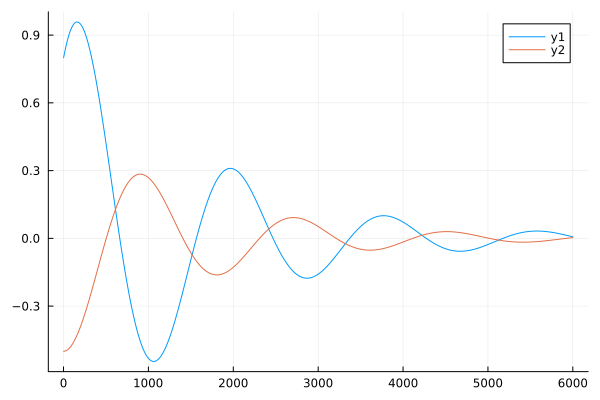

In [211]:


#plot(q1.(ts),p1.(ts),frame=:box,legend=false)
#plot(q[1,:],p[1,:])
plot(q[1,:])
plot!(q[2,:])

In [15]:
using  LinearAlgebra, DelimitedFiles

In [22]:

Ns=2 .^(4:12); T = 30; hs = T ./Ns; ftol_0 = 1e-14


m = length(Ns);

err_q = zeros(m);

err_p = zeros(m);

for i in 1:m

N = Ns[i]; h = T/N;  ts = (0:N)*h;

DEL = DiscreteEL(KineticEnergy,PotentialEnergy,nodes,b,c,h);    
    
q_Num = ComputeTrajectory(DEL,q0_0,p0_0,N,ftol=ftol_0);
p_Num = ConjugateMomenta(DEL,q_Num,steps=N)

    
q1_exact = q1.(ts);  
q2_exact = q2.(ts);  

p1_exact = p1.(ts);  
p2_exact = p2.(ts);  
    

    
 errq1 = abs.(q_Num[1,1:2:end] - q1_exact)
 errq2 = abs.(q_Num[2,1:2:end] - q2_exact)
    
err_q[i] = max(errq1..., errq2...)
    
errp1 = abs.(p_Num[1,:] - p1_exact)
errp2 = abs.(p_Num[2,:] - p2_exact)
    
err_p[i] = max(errp1..., errp2...)


end    

Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


In [24]:
writedlm("/home/hariz/Desktop/RKCQ_1206/errors/q_err_3stage.dat", [hs err_q ])
writedlm("/home/hariz/Desktop/RKCQ_1206/errors/p_err_3stage.dat", [hs err_p])

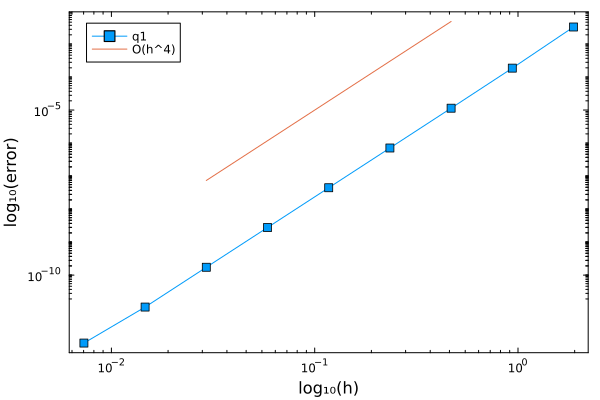

In [23]:
f(x)=0.1*x^4;

plt1=plot(xscale=:log10, yscale=:log10, legend=:topleft,xlabel="log₁₀(h)", ylabel="log₁₀(error)",minorticks=10,grid=false,framestyle=:box)

plot!(plt1,hs , err_p , m =:sq,label="q1")
#plot!(plt1,hs , err_p2 , m =:sq,label="q2")

plot!(plt1,hs[3:end-2] ,  f.(hs)[3:end-2],label="O(h^4)")
